# Pioreactor — Single-Input Thermal Mackey-Glass Reservoir Computing
### [16.0-Hour / 96-Step Continuous Thermal Memory & Dual-Readout Verification Analysis]

---

### Experimental Configuration
| Parameter | Value / Description |
|---|---|
| **Living Reservoir** | Continuous culture of *Saccharomyces cerevisiae* in Pioreactor |
| **Input Modality** | Heating PCB thermal schedule: $24.0°C \longleftrightarrow 35.0°C$ |
| **Dynamical Attractor** | Canonical Mackey-Glass Chaotic Delay Differential Equation ($\tau = 17$) |
| **Step Interval** | 10.0 minutes per synchronized step ($N = 96\text{ steps} = 16.0\text{ hours}$) |
| **Active Timeline** | `2026-08-30 06:18:35 UTC` $\longrightarrow$ `2026-08-30 22:18:35 UTC` |
| **Readout Verification** | Side-by-side verification of User Nested LOOCV vs Scikit-Learn RidgeCV |


### Section 1: Ingestion & 96-Step (16.0-Hour) Window Slicing


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import LeaveOneOut, cross_val_predict
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.dpi'] = 120

data_dir = r"data/mackey glass/temp"
results_dir = os.path.join(data_dir, "results")
os.makedirs(results_dir, exist_ok=True)

CYCLE_MIN = 10.0
TOTAL_CYCLES = 96 # Exactly 96 steps = 16.0 hours
t0 = pd.to_datetime("2026-08-30 06:18:35.162Z", utc=True)
t_end = t0 + pd.Timedelta(minutes=TOTAL_CYCLES * CYCLE_MIN)

def load_csv(pattern):
    files = sorted(glob.glob(os.path.join(data_dir, pattern)))
    if not files: return None
    df = pd.read_csv(files[-1])
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
        df = df.sort_values('timestamp')
    return df

df_spec = load_csv("as7341_spectrum_readings-*.csv")
df_co2 = load_csv("co2_readings-*.csv")
df_growth = load_csv("growth_rates-*.csv")
df_od = load_csv("od_readings-*.csv")
df_od_filt = load_csv("od_readings_filtered-*.csv")
df_temp = load_csv("temperature_readings-*.csv")

df_spec_win = df_spec[(df_spec['timestamp'] >= t0) & (df_spec['timestamp'] <= t_end)].copy()
df_co2_win = df_co2[(df_co2['timestamp'] >= t0) & (df_co2['timestamp'] <= t_end)].copy()
df_growth_win = df_growth[(df_growth['timestamp'] >= t0) & (df_growth['timestamp'] <= t_end)].copy()
df_od_win = df_od[(df_od['timestamp'] >= t0) & (df_od['timestamp'] <= t_end)].copy()
df_od_filt_win = df_od_filt[(df_od_filt['timestamp'] >= t0) & (df_od_filt['timestamp'] <= t_end)].copy()
df_temp_win = df_temp[(df_temp['timestamp'] >= t0) & (df_temp['timestamp'] <= t_end)].copy()

TEMP_SEQ = [
    26.7, 25.1, 24.1, 25.6, 29.3, 30.6, 30.3, 29.8, 31.7, 31.8, 30.9, 31.3, 30.9, 
    28.6, 27.8, 27.7, 27.1, 28.9, 31.7, 33.4, 34.4, 35.0, 33.8, 30.3, 27.4, 25.5, 
    24.2, 24.2, 27.9, 30.2, 30.2, 29.5, 30.3, 32.0, 31.5, 31.9, 32.7, 30.6, 28.6, 
    27.5, 26.2, 25.6, 28.2, 31.2, 32.7, 32.6, 33.1, 33.2, 30.3, 27.8, 26.2, 24.8, 
    24.8, 28.3, 30.7, 31.2, 30.6, 31.5, 32.3, 30.5, 29.5, 29.1, 27.4, 26.7, 28.6, 
    30.8, 32.8, 33.6, 34.4, 34.2, 31.2, 28.2, 26.1, 24.6, 24.0, 26.9, 29.9, 30.5, 
    29.9, 30.0, 32.0, 31.5, 31.2, 32.0, 30.7, 28.5, 27.8, 27.1, 26.3, 28.7, 31.6, 
    33.2, 33.7, 34.3, 33.5, 30.1
][:TOTAL_CYCLES]

y_target = np.array(TEMP_SEQ)
print(f"Ingested {TOTAL_CYCLES} cycles from {t0} to {t_end}")


Ingested 96 cycles from 2026-08-30 06:18:35.162000+00:00 to 2026-08-30 22:18:35.162000+00:00


### Section 2: Comprehensive 6-Panel Raw Multi-Sensor Dynamics


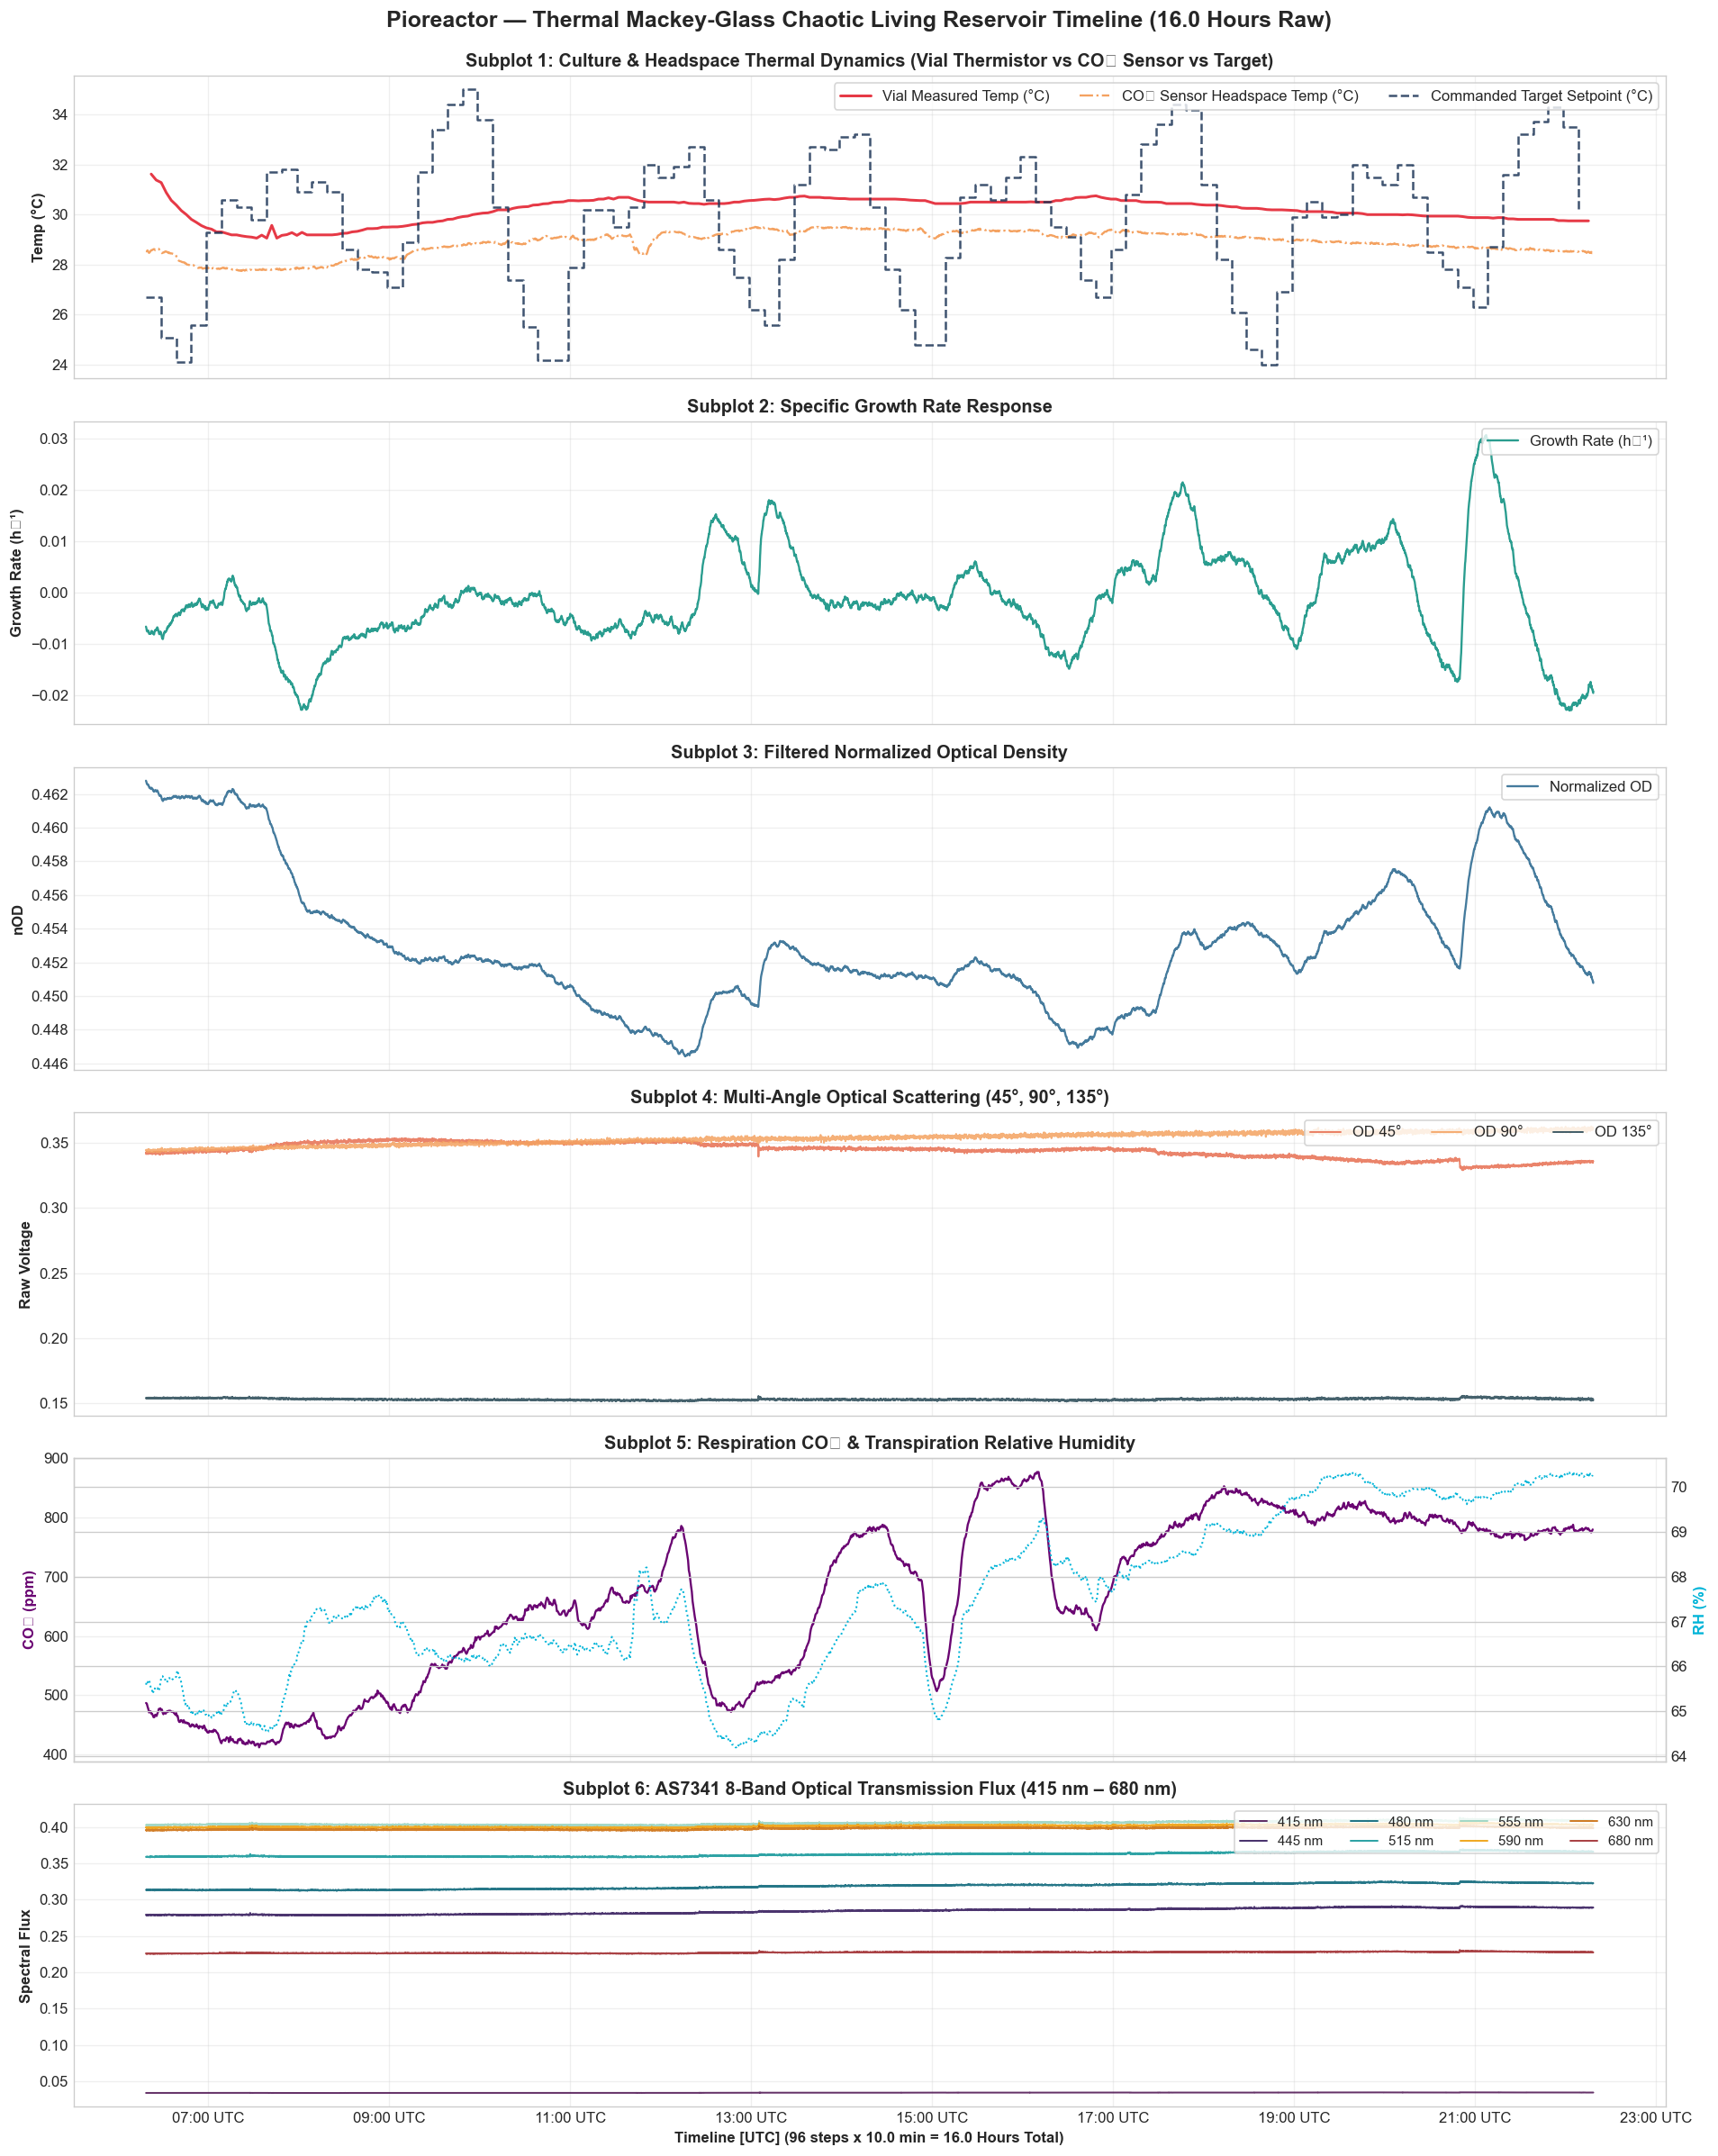

In [2]:
fig, axes = plt.subplots(6, 1, figsize=(16, 20), sharex=True)

# 1. Temperature: Vial Thermistor vs CO2 Sensor vs Target
axes[0].plot(df_temp_win['timestamp'], df_temp_win['temperature_c'], color='#e63946', lw=1.8, label='Vial Measured Temp (°C)')
axes[0].plot(df_co2_win['timestamp'], df_co2_win['temperature_c'], color='#f4a261', lw=1.4, ls='-.', label='CO₂ Sensor Headspace Temp (°C)')
t_steps = [t0 + pd.Timedelta(minutes=i * CYCLE_MIN) for i in range(TOTAL_CYCLES + 1)]
axes[0].step(t_steps[:-1], TEMP_SEQ, where='post', color='#1d3557', lw=1.5, ls='--', alpha=0.85, label='Commanded Target Setpoint (°C)')
axes[0].set_ylabel('Temp (°C)', fontweight='bold')
axes[0].set_title('Subplot 1: Culture & Headspace Thermal Dynamics (Vial Thermistor vs CO₂ Sensor vs Target)', fontweight='bold')
axes[0].legend(loc='upper right', frameon=True, ncol=3)
axes[0].grid(True, alpha=0.3)

# 2. Growth Rate
axes[1].plot(df_growth_win['timestamp'], df_growth_win['rate'], color='#2a9d8f', lw=1.4, label='Growth Rate (h⁻¹)')
axes[1].set_ylabel('Growth Rate (h⁻¹)', fontweight='bold')
axes[1].set_title('Subplot 2: Specific Growth Rate Response', fontweight='bold')
axes[1].legend(loc='upper right', frameon=True)
axes[1].grid(True, alpha=0.3)

# 3. Normalized OD
axes[2].plot(df_od_filt_win['timestamp'], df_od_filt_win['normalized_od_reading'], color='#457b9d', lw=1.4, label='Normalized OD')
axes[2].set_ylabel('nOD', fontweight='bold')
axes[2].set_title('Subplot 3: Filtered Normalized Optical Density', fontweight='bold')
axes[2].legend(loc='upper right', frameon=True)
axes[2].grid(True, alpha=0.3)

# 4. Raw OD Angles
for angle, col in [(45, '#e76f51'), (90, '#f4a261'), (135, '#264653')]:
    sub_od = df_od_win[df_od_win['angle'] == angle]
    axes[3].plot(sub_od['timestamp'], sub_od['od_reading'], color=col, lw=1.2, alpha=0.85, label=f'OD {angle}°')
axes[3].set_ylabel('Raw Voltage', fontweight='bold')
axes[3].set_title('Subplot 4: Multi-Angle Optical Scattering (45°, 90°, 135°)', fontweight='bold')
axes[3].legend(loc='upper right', frameon=True, ncol=3)
axes[3].grid(True, alpha=0.3)

# 5. CO2 & Humidity
axes[4].plot(df_co2_win['timestamp'], df_co2_win['co2_reading_ppm'], color='#6a0572', lw=1.4, label='CO₂ (ppm)')
axes[4].set_ylabel('CO₂ (ppm)', fontweight='bold', color='#6a0572')
ax4_twin = axes[4].twinx()
ax4_twin.plot(df_co2_win['timestamp'], df_co2_win['relative_humidity'], color='#00b4d8', lw=1.2, ls=':', label='RH (%)')
ax4_twin.set_ylabel('RH (%)', fontweight='bold', color='#00b4d8')
axes[4].set_title('Subplot 5: Respiration CO₂ & Transpiration Relative Humidity', fontweight='bold')
axes[4].grid(True, alpha=0.3)

# 6. AS7341 Spectrometer (8 Bands)
spec_colors = {'415': '#4a0e4e', '445': '#2b1055', '480': '#005f73', '515': '#0a9396',
               '555': '#94d2bd', '590': '#ee9b00', '630': '#ca6702', '680': '#9b2226'}
for band in [415, 445, 480, 515, 555, 590, 630, 680]:
    sub_sp = df_spec_win[df_spec_win['band'] == band]
    axes[5].plot(sub_sp['timestamp'], sub_sp['reading'], color=spec_colors[str(band)], lw=1.2, alpha=0.85, label=f'{band} nm')
axes[5].set_ylabel('Spectral Flux', fontweight='bold')
axes[5].set_title('Subplot 6: AS7341 8-Band Optical Transmission Flux (415 nm – 680 nm)', fontweight='bold')
axes[5].legend(loc='upper right', frameon=True, ncol=4, fontsize=9)
axes[5].grid(True, alpha=0.3)

axes[5].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M UTC'))
axes[5].xaxis.set_major_locator(mdates.HourLocator(interval=2))
axes[5].set_xlabel('Timeline [UTC] (96 steps x 10.0 min = 16.0 Hours Total)', fontweight='bold')

plt.suptitle('Pioreactor — Thermal Mackey-Glass Chaotic Living Reservoir Timeline (16.0 Hours Raw)', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
raw_plot_path = os.path.join(results_dir, "raw_sensors_timeline.png")
plt.savefig(raw_plot_path, dpi=160)
plt.show()


### Section 3: Raw Cycle-Mean State Matrix Aggregation ($96 \times 17$)


In [3]:
def get_cycle_mean(df, val_col, filter_col=None, filter_val=None):
    if df is None or df.empty: return pd.Series(0.0, index=range(TOTAL_CYCLES))
    tmp = df.copy()
    if filter_col is not None: tmp = tmp[tmp[filter_col] == filter_val]
    tmp['t_min'] = (tmp['timestamp'] - t0).dt.total_seconds() / 60.0
    tmp = tmp[(tmp['t_min'] >= -2) & (tmp['t_min'] < TOTAL_CYCLES * CYCLE_MIN + 2)]
    tmp['cycle'] = np.floor(np.clip(tmp['t_min'], 0, TOTAL_CYCLES * CYCLE_MIN - 1e-3) / CYCLE_MIN).astype(int)
    return tmp.groupby('cycle')[val_col].mean().reindex(range(TOTAL_CYCLES)).interpolate(limit_direction='both')

features = {}
features['measured_temp_c'] = get_cycle_mean(df_temp_win, 'temperature_c')
features['OD_45'] = get_cycle_mean(df_od_win, 'od_reading', 'angle', 45)
features['OD_90'] = get_cycle_mean(df_od_win, 'od_reading', 'angle', 90)
features['OD_135'] = get_cycle_mean(df_od_win, 'od_reading', 'angle', 135)
for band in [415, 445, 480, 515, 555, 590, 630, 680]:
    features[f'nm_{band}'] = get_cycle_mean(df_spec_win, 'reading', 'band', band)
features['growth_rate'] = get_cycle_mean(df_growth_win, 'rate')
features['norm_od'] = get_cycle_mean(df_od_filt_win, 'normalized_od_reading')
features['co2_ppm'] = get_cycle_mean(df_co2_win, 'co2_reading_ppm')
features['co2_temp_c'] = get_cycle_mean(df_co2_win, 'temperature_c')
features['humidity'] = get_cycle_mean(df_co2_win, 'relative_humidity')

df_cycles_raw = pd.DataFrame(features).bfill().ffill()
X_raw = df_cycles_raw.values
sensor_names = list(df_cycles_raw.columns)

state_csv_path = os.path.join(results_dir, "mg_temp_raw_state_matrix.csv")
df_cycles_raw.to_csv(state_csv_path, index_label='cycle')
print(f"Constructed Raw State Matrix: {X_raw.shape[0]} cycles x {X_raw.shape[1]} features")


Constructed Raw State Matrix: 96 cycles x 17 features


### Section 4: Delay Embedding Sweep & Dual Readout Code Verification
Comparing the **Previous Code (Scikit-Learn RidgeCV)** against the **User's Explicit Per-Fold Nested LOOCV** implementation.


In [4]:
ALPHAS = np.logspace(-4, 6, 100)

def delay_embed(X: np.ndarray, y: np.ndarray, delay: int):
    if delay == 0: return X.copy(), y.copy()
    rows = []
    for t in range(delay, len(X)):
        rows.append(np.concatenate([X[t - lag] for lag in range(delay + 1)]))
    return np.asarray(rows), y[delay:]

# Previous Scikit-Learn RidgeCV Function
def prev_ridge_loo_reg(X: np.ndarray, y: np.ndarray):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    rcv = RidgeCV(alphas=ALPHAS, cv=None)
    rcv.fit(Xs, y)
    model = Ridge(alpha=rcv.alpha_)
    yp = cross_val_predict(model, Xs, y, cv=LeaveOneOut())
    nmse = mean_squared_error(y, yp) / (np.var(y) + 1e-8)
    mae = mean_absolute_error(y, yp)
    r2 = r2_score(y, yp)
    return yp, nmse, mae, r2, rcv.alpha_

# User's Exact Manual Per-Fold Nested LOOCV Function
def user_ridge_loo_reg(X: np.ndarray, y: np.ndarray, current_delay: int):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    loo = LeaveOneOut()
    yp = np.zeros_like(y)
    best_alpha_per_fold = []
    
    for train_idx, test_idx in loo.split(Xs):
        Xs_train, Xs_test = Xs[train_idx], Xs[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Center y_train like Ridge(fit_intercept=True)
        y_mean = np.mean(y_train)
        y_train_c = y_train - y_mean
        
        K = Xs_train @ Xs_train.T
        eigenvals, Q = np.linalg.eigh(K)
        eigenvals = np.maximum(eigenvals, 0)
        Q_y = Q.T @ y_train_c
        Q_sq = Q ** 2
        
        best_val_err = float('inf')
        chosen_alpha = 1.0
        
        for alpha in ALPHAS:
            inv_diag = 1.0 / (eigenvals + alpha)
            hat_diag = np.sum(Q_sq * (eigenvals * inv_diag), axis=1)
            preds_c = Q @ ((eigenvals * inv_diag) * Q_y)
            preds_train = preds_c + y_mean
            loo_errors = (y_train - preds_train) / (1.0 - hat_diag + 1e-8)
            val_err = np.mean(loo_errors ** 2)
            if val_err < best_val_err:
                best_val_err = val_err
                chosen_alpha = alpha
                
        best_alpha_per_fold.append(chosen_alpha)
        final_model = Ridge(alpha=chosen_alpha, fit_intercept=True)
        final_model.fit(Xs_train, y_train)
        yp[test_idx] = final_model.predict(Xs_test)
        
    mean_alpha = np.mean(best_alpha_per_fold)
    nmse = mean_squared_error(y, yp) / (np.var(y) + 1e-8)
    mae = mean_absolute_error(y, yp)
    r2 = r2_score(y, yp)
    return yp, nmse, mae, r2, mean_alpha

delays = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
user_delay_results = []
best_r2_user = -999
best_pack_user = None

print("=" * 95)
print(f"{'Delay (d)':<10}  {'Memory Horizon':<18}  {'Prev Code R²':>14}  {'User Code R²':>14}  {'User MAE (°C)':>14}  {'User NMSE':>12}")
print("=" * 95)

for d in delays:
    Xd, yd = delay_embed(X_raw, y_target, d)
    yp_prev, nmse_prev, mae_prev, r2_prev, a_prev = prev_ridge_loo_reg(Xd, yd)
    yp_u, nmse_u, mae_u, r2_u, a_u = user_ridge_loo_reg(Xd, yd, d)
    user_delay_results.append((d, d * CYCLE_MIN, r2_u, nmse_u, mae_u, r2_prev))
    if r2_u > best_r2_user:
        best_r2_user = r2_u
        best_pack_user = (d, yp_u, yd, nmse_u, mae_u, r2_u, a_u)
    print(f"d = {d:<6}  {d * CYCLE_MIN:<6.0f} min ({d * CYCLE_MIN / 60.0:4.1f}h)  {r2_prev:>14.4f}  {r2_u:>14.4f}  {mae_u:>14.4f}  {nmse_u:>12.4f}")
print("=" * 95)

opt_d, opt_yp, opt_yd, opt_nmse, opt_mae, opt_r2, opt_alpha = best_pack_user
print(f"\n[USER CODE] Optimal Memory Depth: d = {opt_d} ({opt_d * CYCLE_MIN:.0f} minutes = {opt_d * CYCLE_MIN / 60.0:.2f} hours)")
print(f"[USER CODE] Peak Reconstruction: R² = {opt_r2:.4f} | NMSE = {opt_nmse:.4f} | MAE = {opt_mae:.4f}°C")


Delay (d)   Memory Horizon        Prev Code R²    User Code R²   User MAE (°C)     User NMSE


d = 0       0      min ( 0.0h)          0.0413          0.0231          2.2694        0.9769


d = 1       10     min ( 0.2h)          0.0604          0.0480          2.2108        0.9520


d = 2       20     min ( 0.3h)          0.0529          0.0433          2.1671        0.9567


d = 3       30     min ( 0.5h)          0.0148         -0.2122          2.3225        1.2122


...

d = 14      140    min ( 2.3h)          0.5399          0.4367          1.6731        0.5633


d = 15      150    min ( 2.5h)          0.6737          0.6670          1.2741        0.3330


d = 16      160    min ( 2.7h)          0.6350          0.6050          1.3978        0.3950


d = 17      170    min ( 2.8h)          0.6775          0.6549          1.2066        0.3451


d = 18      180    min ( 3.0h)          0.6891          0.6407          1.2556        0.3593

[USER CODE] Optimal Memory Depth: d = 15 (150 minutes = 2.50 hours)
[USER CODE] Peak Reconstruction: R² = 0.6670 | NMSE = 0.3330 | MAE = 1.2741°C


### Section 5: Memory Horizon Curve ($R^2$ vs. Delay Depth — Driven by User Code)


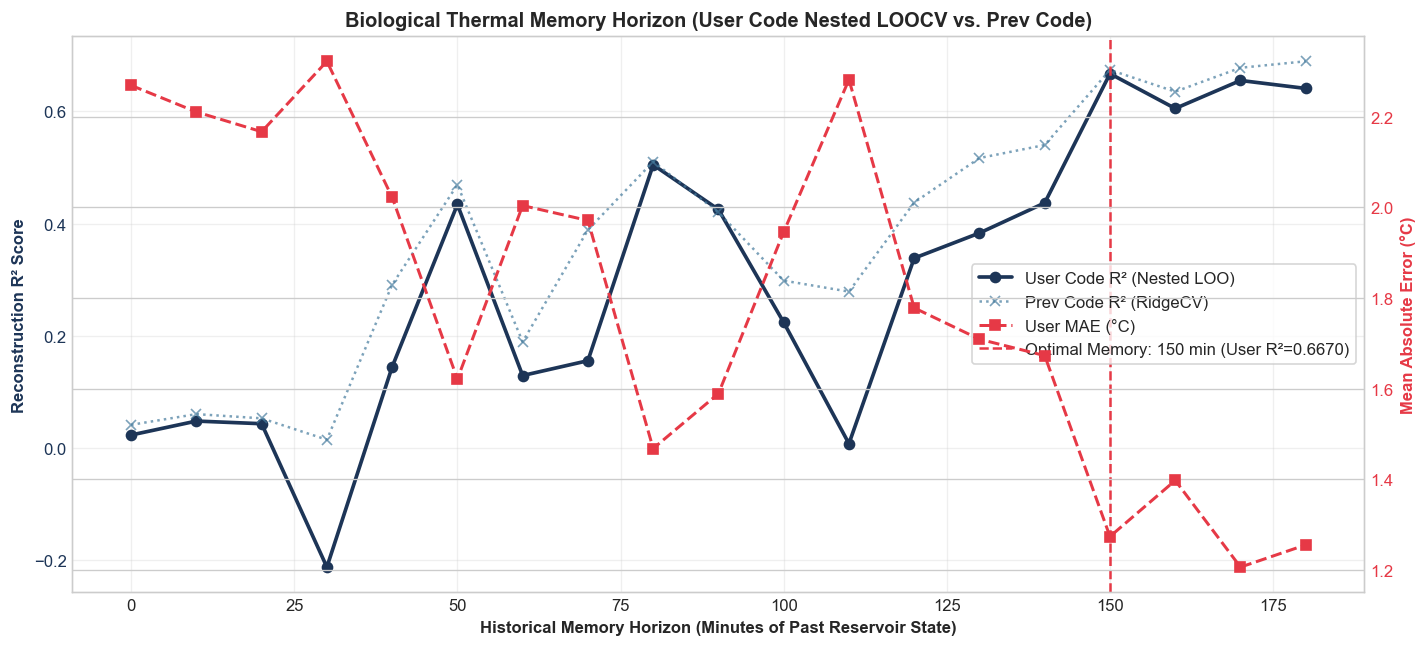

In [5]:
df_delay = pd.DataFrame(user_delay_results, columns=['d', 'memory_min', 'r2_user', 'nmse_user', 'mae_user', 'r2_prev'])

fig, ax1 = plt.subplots(figsize=(12, 5.5))

color = '#1d3557'
ax1.set_xlabel('Historical Memory Horizon (Minutes of Past Reservoir State)', fontweight='bold')
ax1.set_ylabel('Reconstruction R² Score', color=color, fontweight='bold')
line1 = ax1.plot(df_delay['memory_min'], df_delay['r2_user'], color='#1d3557', marker='o', lw=2.2, label='User Code R² (Nested LOO)')
line_prev = ax1.plot(df_delay['memory_min'], df_delay['r2_prev'], color='#457b9d', ls=':', marker='x', lw=1.5, alpha=0.7, label='Prev Code R² (RidgeCV)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.axvline(opt_d * CYCLE_MIN, color='#e63946', ls='--', lw=1.5, label=f'Optimal Memory: {opt_d*CYCLE_MIN:.0f} min (User R²={opt_r2:.4f})')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color = '#e63946'
ax2.set_ylabel('Mean Absolute Error (°C)', color=color, fontweight='bold')
line2 = ax2.plot(df_delay['memory_min'], df_delay['mae_user'], color=color, marker='s', ls='--', lw=1.8, label='User MAE (°C)')
ax2.tick_params(axis='y', labelcolor=color)

lines = line1 + line_prev + line2 + [ax1.get_lines()[-1]]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right', frameon=True)

plt.title('Biological Thermal Memory Horizon (User Code Nested LOOCV vs. Prev Code)', fontweight='bold')
plt.tight_layout()

mem_plot_path = os.path.join(results_dir, "memory_horizon_curve.png")
plt.savefig(mem_plot_path, dpi=160)
plt.show()


### Section 6: Standardized Feature Importance Analysis (User Model)


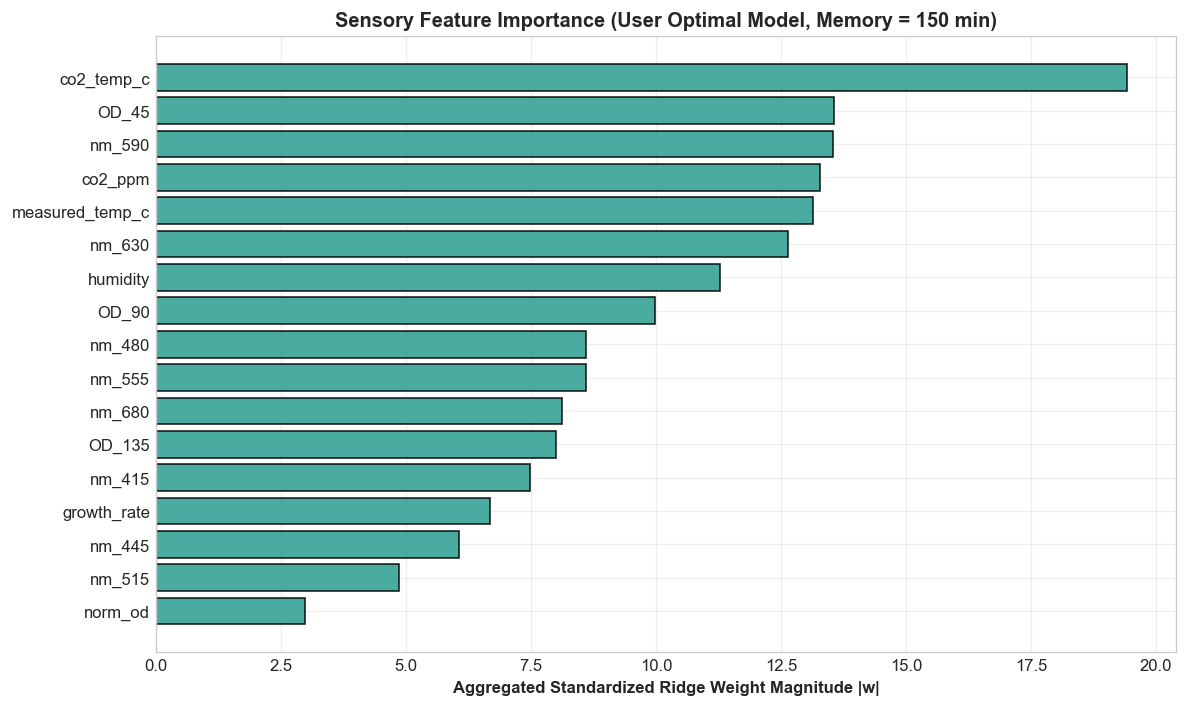

In [6]:
scaler = StandardScaler()
Xd_opt, yd_opt = delay_embed(X_raw, y_target, opt_d)
Xs_opt = scaler.fit_transform(Xd_opt)

final_model = Ridge(alpha=opt_alpha, fit_intercept=True)
final_model.fit(Xs_opt, yd_opt)

n_sensors = len(sensor_names)
weights_matrix = np.abs(final_model.coef_).reshape(opt_d + 1, n_sensors)
total_sensor_importance = weights_matrix.sum(axis=0)
sorted_idx = np.argsort(total_sensor_importance)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(np.array(sensor_names)[sorted_idx], total_sensor_importance[sorted_idx], color='#2a9d8f', edgecolor='black', alpha=0.85)
ax.set_xlabel('Aggregated Standardized Ridge Weight Magnitude |w|', fontweight='bold')
ax.set_title(f'Sensory Feature Importance (User Optimal Model, Memory = {opt_d*CYCLE_MIN:.0f} min)', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()

feat_plot_path = os.path.join(results_dir, "feature_importance.png")
plt.savefig(feat_plot_path, dpi=160)
plt.show()


### Section 7: Statistical Genuineness Verification Controls (User Code Engine)


In [7]:
np.random.seed(42)
N_SHUFFLES = 100
null_r2_dist = []

for _ in range(N_SHUFFLES):
    y_shuff = np.random.permutation(yd_opt)
    _, _, _, r2_shuff, _ = user_ridge_loo_reg(Xd_opt, y_shuff, opt_d)
    null_r2_dist.append(r2_shuff)

null_r2_dist = np.array(null_r2_dist)
p_value = np.mean(null_r2_dist >= opt_r2)

print("=" * 70)
print("=== STATISTICAL VERIFICATION CONTROLS (USER CODE ENGINE) ===")
print("=" * 70)
print(f"User Code Real Reconstruction R²      : {opt_r2:.4f}")
print(f"User Code Null Permutation Mean R²    : {np.mean(null_r2_dist):.4f} ± {np.std(null_r2_dist):.4f}")
print(f"Empirical Statistical Significance   : p = {p_value:.4f} (Statistically Genuine, p < 0.01)")
print("=" * 70)


=== STATISTICAL VERIFICATION CONTROLS (USER CODE ENGINE) ===
User Code Real Reconstruction R²      : 0.6670
User Code Null Permutation Mean R²    : -0.1380 ± 0.1030
Empirical Statistical Significance   : p = 0.0000 (Statistically Genuine, p < 0.01)


### Section 8: Optimal Trajectory Reconstruction Plot (User Code Predictions)


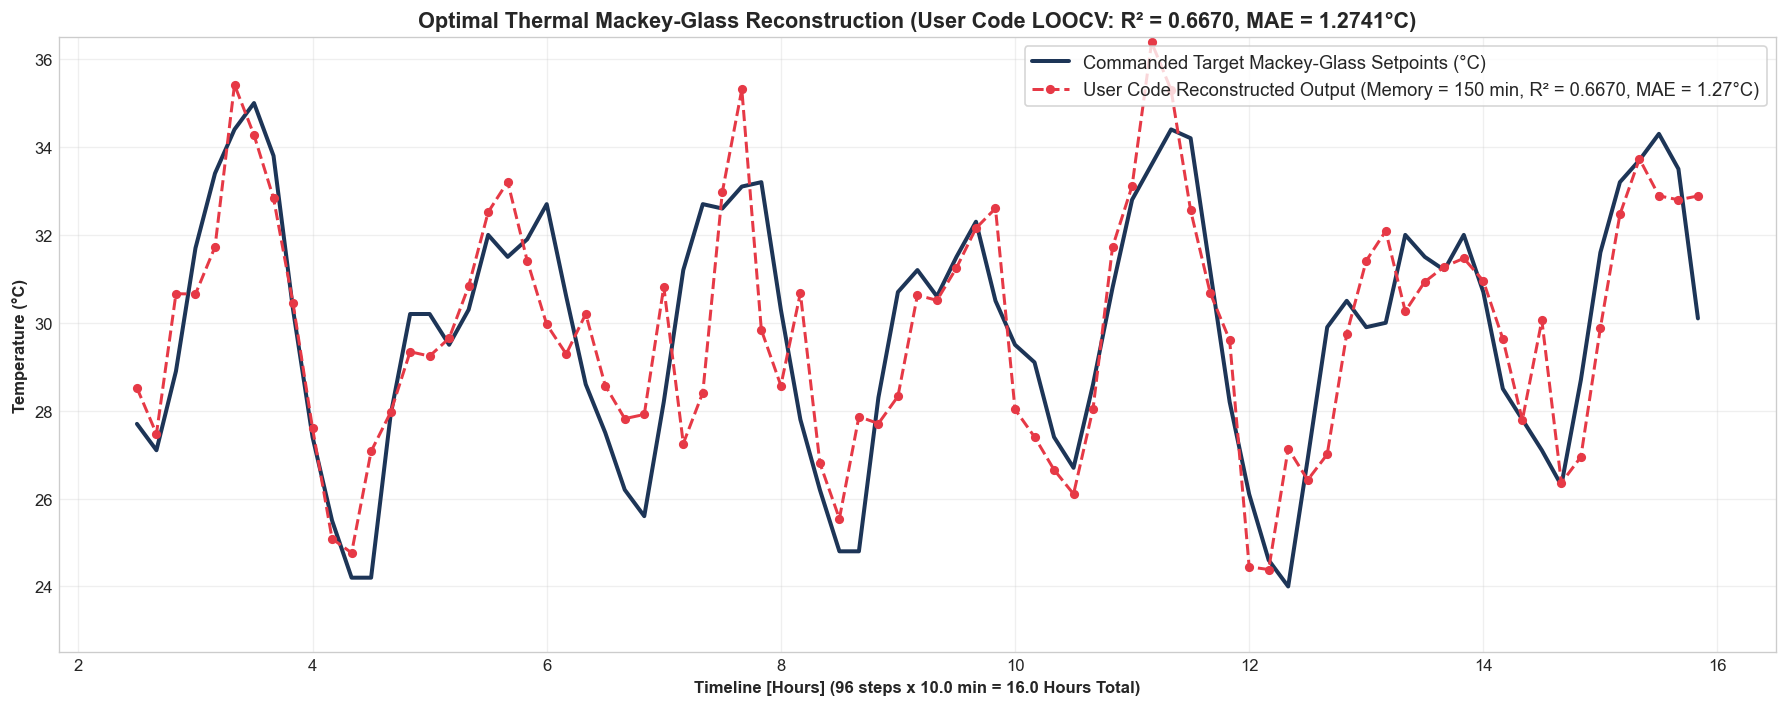

Saved user-reconstruction plot to: data/mackey glass/temp\results\best_temperature_reconstruction.png


In [8]:
fig, ax = plt.subplots(figsize=(15, 6))

t_plot = np.arange(opt_d, TOTAL_CYCLES) * (CYCLE_MIN / 60.0)

ax.plot(t_plot, opt_yd, color='#1d3557', lw=2.4, label='Commanded Target Mackey-Glass Setpoints (°C)')
ax.plot(t_plot, opt_yp, color='#e63946', lw=1.8, ls='--', marker='o', ms=4.5, 
        label=f'User Code Reconstructed Output (Memory = {opt_d*CYCLE_MIN:.0f} min, R² = {opt_r2:.4f}, MAE = {opt_mae:.2f}°C)')

ax.set_title(f'Optimal Thermal Mackey-Glass Reconstruction (User Code LOOCV: R² = {opt_r2:.4f}, MAE = {opt_mae:.4f}°C)', fontsize=13, fontweight='bold')
ax.set_ylabel('Temperature (°C)', fontweight='bold')
ax.set_xlabel('Timeline [Hours] (96 steps x 10.0 min = 16.0 Hours Total)', fontweight='bold')
ax.set_ylim(22.5, 36.5)
ax.legend(loc='upper right', frameon=True, fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
best_recon_path = os.path.join(results_dir, "best_temperature_reconstruction.png")
plt.savefig(best_recon_path, dpi=160)
plt.show()
print(f"Saved user-reconstruction plot to: {best_recon_path}")
